# Model Experimentation — Day 3

This experiment focuses on `target_aqi_day3`.

## Approach

1. Load the full 49-feature modeling dataset and create chronological train/validation/test splits.
2. Combine the training and validation sets into a single pool for feature selection, hyperparameter tuning, and model comparison.
3. Keep the test set completely untouched until the final evaluation.
4. Experiment with **Random Forest**, applying RFECV with `TimeSeriesSplit(5)` and tuning the selected feature set using time-series cross-validation.
5. Experiment with **Ridge Regression**, applying the existing preprocessing, RFECV, and alpha tuning using `TimeSeriesSplit(5)`.
6. Experiment with **XGBoost**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
7. Experiment with **LightGBM**, applying RFECV and hyperparameter tuning using `TimeSeriesSplit(5)`.
8. Experiment with **MLP** using the feature subset selected by Ridge RFECV, manually evaluating architecture variants across the same five time-series folds.
9. Compare the five model types using their CV-averaged R², RMSE, and MAE.
10. Select the best-performing configuration for Day 1 based only on cross-validation results.
11. Retrain the winning configuration on the full train+validation pool.
12. Evaluate the final Day 1 model once on the untouched test set.
13. Record the final test metrics and selected configuration for the Day 1 experiment.

In [1]:
import random

from src.common.constants import ALL_LOG_TRANSFORM_FEATURES, ALL_TRAINING_FEATURES, TARGET_COLUMNS
from src.modeling.data_utils import load_modeling_data, split_modeling_data, preprocess_data

import shap
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFECV
from sklearn.model_selection import GridSearchCV
from tensorflow.keras import layers, regularizers
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

In [5]:
df = load_modeling_data()

train_df, val_df, test_df = split_modeling_data(df)

target_label = ["target_aqi_day3"]

In [6]:
train_df_preprocess, val_df_preprocess, test_df_preprocess = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [7]:
train_val_df = pd.concat(
    [train_df, val_df],
    axis=0,
).sort_values("ts").reset_index(drop=True)

train_val_df_preprocess = pd.concat(
    [train_df_preprocess, val_df_preprocess],
    axis=0,
).sort_values("ts").reset_index(drop=True)

X = train_val_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_preprocess = train_val_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y = train_val_df_preprocess[target_label].to_numpy().ravel()

X_test = test_df.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

X_test_preprocess = test_df_preprocess.drop(
    columns=["ts"] + TARGET_COLUMNS,
)

y_test = test_df[target_label].to_numpy().ravel()

tscv = TimeSeriesSplit(n_splits=5)

In [8]:
def pred_test(model, model_type, tuned_on, X_test_req = X_test_preprocess, features = None):
    if features is None:
        y_test_pred = model.predict(X_test_req).ravel()
    else:
        y_test_pred = model.predict(X_test_req[features]).ravel()


    r2 = r2_score(y_test, y_test_pred)
    rmse = root_mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)

    print("=" * 40)
    print(f"       {model_type} (Tuned on {tuned_on} Feature Set) — Day 1")
    print("=" * 40)
    print(f"R²   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print("=" * 40)

def perform_rfecv(model, X_req = X_preprocess):
    rfecv = RFECV(
        estimator=model,
        step=1,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

    rfecv.fit(X_req, y)

    selected_features = X_req.columns[rfecv.support_]

    X_selected = X_req[selected_features]

    print(f"Selected features: {len(selected_features)} / {X_req.shape[1]}")
    print("\nSelected feature set:")
    print(list(selected_features))

    return selected_features, X_selected

def get_random_search(model):
    return RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="r2",
        cv=tscv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )

def tune_hyperparameter(X_df, model_func, search_func):
    model = model_func()

    search = search_func(model)

    search.fit(X_df, y)

    best_model = search.best_estimator_

    print("Best parameters:")
    print(search.best_params_)

    print("\nBest CV R²:")
    print(search.best_score_)

    return best_model

## Experiment 1 — Random Forest

This experiment focuses exclusively on `target_aqi_day3` using Random Forest.

The goal is to determine the best-performing Random Forest configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
3. Tuning the Random Forest hyperparameters using `TimeSeriesSplit(5)`.
4. Retraining the finalized Random Forest on the full train+validation pool.
5. Evaluating the final model once on the untouched test set.

In [9]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.75, 1.0],
}

def get_random_forest_model():
    return RandomForestRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_random_forest_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_random_forest_model, get_random_search)

In [10]:
best_model_random_forest = tune_random_forest_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'max_depth': 15}

Best CV R²:
0.3343144483771495


In [11]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.5401
RMSE : 31.7439
MAE  : 24.0873


In [12]:
# Feature selection
random_forest = get_random_forest_model()

random_forest_rfecv_features, X_selected = perform_rfecv(random_forest, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Selected features: 45 / 49

Selected feature set:
['aqi_today', 'aqi_lag_2', 'aqi_lag_3', 'aqi_roll_mean_3', 'aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'aqi_change_rate', 'pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today', 'dew_pt_today', 'pm25_lag_1', 'pm10_lag_1', 'o3_lag_1', 'pm25_lag_2', 'o3_lag_2', 'pm25_lag_3', 'pm10_lag_3', 'o3_lag_3', 'temp_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'wind_spd_lag_1', 'dew_pt_lag_1', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_roll_std_3', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_std_3', 'o3_roll_std_7', 'month']


In [13]:
best_model_random_forest_rfecv = tune_random_forest_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': 10}

Best CV R²:
0.32460060466794627


In [14]:
pred_test(best_model_random_forest, "Random Forest", "Full", X_test_req=X_test)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Random Forest (Tuned on Full Feature Set) — Day 1
R²   : 0.5401
RMSE : 31.7439
MAE  : 24.0873
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5386
RMSE : 31.7981
MAE  : 24.0351


## Experiment 2 — Ridge Regression

This experiment focuses exclusively on `target_aqi_day3` using Ridge Regression.

The goal is to determine the best-performing Ridge Regression configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Applying the existing preprocessing approach with `log1p` transformations where applicable and `RobustScaler`.
3. Applying RFECV with `TimeSeriesSplit(5)` for feature selection.
4. Tuning the Ridge `alpha` hyperparameter using `TimeSeriesSplit(5)`.
5. Recording the mean cross-validation R², RMSE, and MAE across the five time-series folds.
6. Retraining the finalized Ridge model on the full train+validation pool.
7. Evaluating the final model once on the untouched test set.

In [15]:
param_distributions = {
    "alpha": [
        0.001,
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
        1000.0,
    ],
}

def get_ridge_model():
    return Ridge(
        random_state=42,
    )

def get_grid_search(ridge_model):
    return GridSearchCV(
        estimator=ridge_model,
        param_grid=param_distributions,
        scoring="r2",
        cv=tscv,
        n_jobs=-1,
        verbose=1,
    )

def tune_ridge_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_ridge_model, get_grid_search)

In [16]:
best_model_ridge_regression = tune_ridge_hyperparameter(X_preprocess)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 100.0}

Best CV R²:
0.32627322930862596


In [17]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.5061
RMSE : 32.8985
MAE  : 24.8301


In [18]:
ridge_regression = get_ridge_model()

ridge_regression_rfecv_features, X_selected = perform_rfecv(ridge_regression)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Fitting estimator with 25 features.
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 fe

In [19]:
best_model_ridge_regression_rfecv = tune_ridge_hyperparameter(X_selected)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters:
{'alpha': 10.0}

Best CV R²:
0.3105164555714288


In [20]:
pred_test(best_model_ridge_regression, "Ridge Regression", "Full")
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)

       Ridge Regression (Tuned on Full Feature Set) — Day 1
R²   : 0.5061
RMSE : 32.8985
MAE  : 24.8301
       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5397
RMSE : 31.7600
MAE  : 23.4443


In [21]:
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)
pred_test(best_model_random_forest_rfecv, "Random Forest", "RFCEV", X_test_req=X_test, features=random_forest_rfecv_features)

       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5397
RMSE : 31.7600
MAE  : 23.4443
       Random Forest (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5386
RMSE : 31.7981
MAE  : 24.0351


## Experiment 3 — XGBoost

This experiment focuses exclusively on `target_aqi_day3` using XGBoost.

The goal is to determine the best-performing XGBoost configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main XGBoost hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `max_depth`
   - `learning_rate`
   - `min_child_weight`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Using early stopping only if it can be implemented without contaminating the cross-validation evaluation; otherwise, relying on the CV-selected `n_estimators` and regularization parameters.
7. Retraining the finalized XGBoost model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [22]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_xgboost_model():
    return XGBRegressor(
        random_state=42,
        n_jobs=-1,
    )

def tune_xgboost_hyperparameter(X_df):
    return tune_hyperparameter(X_df, get_xgboost_model, get_random_search)

In [23]:
best_model_xgboost = tune_xgboost_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.27806497779962813


In [24]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.5427
RMSE : 31.6544
MAE  : 24.8108


In [25]:
xgboost = get_xgboost_model()

xgboost_rfecv_features, X_selected = perform_rfecv(xgboost, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Selected features: 46 / 49

Selected feature set:
['aqi_lag_2', 'aqi_lag_3', 'aqi_roll_mean_3', 'aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'aqi_change_rate', 'pm25_today', 'pm10_today', 'o3_today', 'co_today', 'no2_today', 'so2_today', 'temp_today', 'pressure_today', 'humidity_today', 'wind_spd_today', 'dew_pt_today', 'pm25_lag_1', 'pm10_lag_1', 'o3_lag_1', 'pm25_lag_2', 'pm10_lag_2', 'o3_lag_2', 'pm25_lag_3', 'pm10_lag_3', 'o3_lag_3', 'temp_lag_1', 'pressure_lag_1', 'humidity_lag_1', 'wind_spd_lag_1', 'dew_pt_lag_1', 'pm25_roll_mean_3', 'pm25_roll_mean_7', 'pm10_roll_mean_3', 'pm10_roll_mean_7', 'o3_roll_mean_3', 'o3_roll_mean_7', 'pm25_roll_std_3', 'pm25_roll_std_7', 'pm10_roll_std_3', 'pm10_roll_std_7', 'o3_roll_std_3', 'o3_roll_std_7', 'day_of_week', 'month']


In [26]:
best_model_xgboost_rfecv = tune_xgboost_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Best CV R²:
0.24450477482108984


In [27]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_xgboost_rfecv, "XGBoost", "RFCEV", X_test_req=X_test, features=xgboost_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.5427
RMSE : 31.6544
MAE  : 24.8108
       XGBoost (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5344
RMSE : 31.9411
MAE  : 24.6903


In [28]:
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)
pred_test(best_model_ridge_regression_rfecv, "Ridge Regression", "RFCEV", features=ridge_regression_rfecv_features)

       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.5427
RMSE : 31.6544
MAE  : 24.8108
       Ridge Regression (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5397
RMSE : 31.7600
MAE  : 23.4443


## Experiment 4 — LightGBM

This experiment focuses exclusively on `target_aqi_day3` using LightGBM.

The goal is to determine the best-performing LightGBM configuration for Day 1 by:

1. Using all 49 engineered features except `ts`.
2. Applying RFECV with `TimeSeriesSplit(5)` and `scoring="r2"` for feature selection.
3. Taking the CV-selected feature subset for subsequent model tuning.
4. Tuning the main LightGBM hyperparameters using `GridSearchCV` or `RandomizedSearchCV` with the same `TimeSeriesSplit(5)`, including:
   - `n_estimators`
   - `num_leaves`
   - `max_depth`
   - `learning_rate`
   - `min_child_samples`
   - `subsample`
   - `colsample_bytree`
   - `reg_alpha`
   - `reg_lambda`
5. Recording the mean cross-validation R², RMSE, and MAE across all five time-series folds.
6. Keeping the model configuration reasonably constrained due to the relatively small dataset, prioritizing regularization over an excessively large hyperparameter search.
7. Retraining the finalized LightGBM model on the full train+validation pool.
8. Evaluating the final model once on the untouched test set.

In [29]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "num_leaves": [15, 31, 50, 75],
    "max_depth": [-1, 3, 5, 7, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.1, 1.0, 10.0],
}


def get_lightgbm_model():
    return LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )


def tune_lightgbm_hyperparameter(X_df):
    return tune_hyperparameter(
        X_df,
        get_lightgbm_model,
        get_random_search,
    )

In [30]:
best_model_lightbgm = tune_lightgbm_hyperparameter(X)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0, 'num_leaves': 75, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV R²:
0.3046642887301453


In [31]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.5607
RMSE : 31.0248
MAE  : 24.1672


In [32]:
lightbgm = get_lightgbm_model()

lightbgm_rfecv_features, X_selected = perform_rfecv(lightbgm, X_req=X)

Fitting estimator with 49 features.
Fitting estimator with 48 features.
Fitting estimator with 47 features.
Fitting estimator with 46 features.
Fitting estimator with 45 features.
Fitting estimator with 44 features.
Fitting estimator with 43 features.
Fitting estimator with 42 features.
Fitting estimator with 41 features.
Fitting estimator with 40 features.
Fitting estimator with 39 features.
Fitting estimator with 38 features.
Fitting estimator with 37 features.
Fitting estimator with 36 features.
Fitting estimator with 35 features.
Fitting estimator with 34 features.
Fitting estimator with 33 features.
Fitting estimator with 32 features.
Fitting estimator with 31 features.
Fitting estimator with 30 features.
Fitting estimator with 29 features.
Fitting estimator with 28 features.
Fitting estimator with 27 features.
Fitting estimator with 26 features.
Selected features: 25 / 49

Selected feature set:
['aqi_roll_mean_7', 'aqi_roll_std_3', 'aqi_roll_std_7', 'pm25_today', 'pm10_today', 'c

In [33]:
best_model_lightbgm_rfecv = tune_lightgbm_hyperparameter(X_selected)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.6, 'reg_lambda': 10.0, 'reg_alpha': 0, 'num_leaves': 75, 'n_estimators': 100, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best CV R²:
0.28481557112631206


In [34]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_lightbgm_rfecv, "LightBGM", "RFCEV", X_test_req=X_test, features=lightbgm_rfecv_features)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.5607
RMSE : 31.0248
MAE  : 24.1672
       LightBGM (Tuned on RFCEV Feature Set) — Day 1
R²   : 0.5455
RMSE : 31.5578
MAE  : 24.0390


In [35]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(best_model_xgboost, "XGBoost", "Full", X_test_req=X_test)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.5607
RMSE : 31.0248
MAE  : 24.1672
       XGBoost (Tuned on Full Feature Set) — Day 1
R²   : 0.5427
RMSE : 31.6544
MAE  : 24.8108


## Experiment 5 — MLP with Fixed Architecture (Full Feature Set)

This experiment focuses exclusively on `target_aqi_day3` using a Multi-Layer Perceptron (MLP).

The goal is to evaluate a fixed MLP configuration for Day 1 using the full engineered feature set by:

1. Using all engineered features except `ts` and the target columns.
2. Using the existing chronological train, validation, and test split.
3. Applying the existing preprocessing pipeline to the feature data.
4. Using a fixed MLP architecture with:

   * 64-unit hidden layer with ReLU activation.
   * 32-unit hidden layer with ReLU activation.
   * L2 regularization on both hidden layers.
   * Dropout of 0.1 after each hidden layer.
   * Linear output layer for regression.
5. Using the Adam optimizer with a learning rate of `1e-3`.
6. Using MSE as the training loss.
7. Training for up to 500 epochs with batch size 32.
8. Applying early stopping based on validation loss (`val_loss`) with patience of 15 epochs and restoring the best model weights.
9. Evaluating the trained model on the untouched test set using R², RMSE, and MAE.


In [36]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

X_test_preprocess_mlp = test_df_preprocess[ALL_TRAINING_FEATURES]

In [37]:
def get_mlp_model(input_dim):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(
                64,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(
                32,
                activation="relu",
                kernel_regularizer=regularizers.l2(1e-4),
            ),
            layers.Dropout(0.1),
            layers.Dense(1, activation="linear"),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mse",
    )

    return model


def get_mlp_data(train_df, val_df, features=None):
    if features is None:
        features = ALL_TRAINING_FEATURES

    X_train = train_df[features]
    y_train = train_df[target_label]

    X_val = val_df[features]
    y_val = val_df[target_label]

    return X_train, y_train, X_val, y_val


def train_mlp_model(
    model,
    train_df,
    val_df,
    features=None,
):
    X_train, y_train, X_val, y_val = get_mlp_data(
        train_df,
        val_df,
        features=features,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1,
    )

    return model

In [38]:
mlp_model = get_mlp_model(49)

mlp_model = train_mlp_model(mlp_model, train_df_preprocess, val_df_preprocess)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25422.0039 - val_loss: 25036.8086
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23591.9297 - val_loss: 22656.8418
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19244.4570 - val_loss: 17566.5352
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12712.4932 - val_loss: 10932.5605
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7803.8965 - val_loss: 6551.3271
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5898.5190 - val_loss: 5065.3379
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4921.4775 - val_loss: 4463.7437
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4315.5249 - val_loss: 3919.9319
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3911.6052 - val_loss: 3458.5620
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3180.1416 - val_loss: 2980.6763
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2894.0857 - val_loss

In [39]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.5137
RMSE : 32.6420
MAE  : 25.4350


In [40]:
mlp_model_random_forest_rfecv = get_mlp_model(len(random_forest_rfecv_features))

mlp_model_random_forest_rfecv = train_mlp_model(mlp_model_random_forest_rfecv, train_df_preprocess, val_df_preprocess, features=random_forest_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 25316.9199 - val_loss: 24834.0371
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23465.1309 - val_loss: 22196.4766
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18828.7598 - val_loss: 16463.9238
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11617.7266 - val_loss: 9341.0986
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7068.1108 - val_loss: 5726.3809
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5709.6523 - val_loss: 4737.2241
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4949.2319 - val_loss: 4042.9697
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4273.2017 - val_loss: 3449.4983
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3678.5400 - val_loss: 3001.2517
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3210.1848 - val_loss: 2556.7185
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2853.5874 - val_loss:

In [41]:
pred_test(mlp_model, "MLP", "Full", X_test_req=X_test_preprocess_mlp)
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Full Feature Set) — Day 1
R²   : 0.5137
RMSE : 32.6420
MAE  : 25.4350
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.5252
RMSE : 32.2560
MAE  : 25.1177


In [42]:
mlp_model_ridge_regression_rfecv = get_mlp_model(len(ridge_regression_rfecv_features))

mlp_model_ridge_regression_rfecv = train_mlp_model(mlp_model_ridge_regression_rfecv, train_df_preprocess, val_df_preprocess, features=ridge_regression_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25773.8867 - val_loss: 25708.1211
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25328.6895 - val_loss: 25050.6992
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24190.3730 - val_loss: 23435.0859
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21789.5566 - val_loss: 20400.9141
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17834.7969 - val_loss: 15820.0068
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12749.2441 - val_loss: 10474.8604
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7791.0332 - val_loss: 5903.6147
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4546.0366 - val_loss: 3228.1431
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2980.7219 - val_loss: 2093.5129
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2284.3066 - val_loss: 1642.9452
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2055.7109 - val_

In [43]:
pred_test(mlp_model_random_forest_rfecv, "MLP", "Random Forest RFECV", X_test_req=X_test_preprocess_mlp, features=random_forest_rfecv_features)
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Random Forest RFECV Feature Set) — Day 1
R²   : 0.5252
RMSE : 32.2560
MAE  : 25.1177
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.5294
RMSE : 32.1133
MAE  : 23.9701


In [44]:
mlp_model_xgboost_rfecv = get_mlp_model(len(xgboost_rfecv_features))

mlp_model_xgboost_rfecv = train_mlp_model(mlp_model_xgboost_rfecv, train_df_preprocess, val_df_preprocess, features=xgboost_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25569.9258 - val_loss: 25144.2363
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24085.4707 - val_loss: 23246.7422
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20510.9551 - val_loss: 18857.2910
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14147.0732 - val_loss: 12020.9580
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7982.6362 - val_loss: 6611.8267
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5680.0078 - val_loss: 4950.8779
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4871.3833 - val_loss: 4330.8530
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4149.0122 - val_loss: 3723.0427
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3657.9417 - val_loss: 3266.5354
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3153.7202 - val_loss: 2842.9158
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2830.8945 - val_loss

In [45]:
pred_test(mlp_model_ridge_regression_rfecv, "MLP", "Ridge Regression RFECV", X_test_req=X_test_preprocess_mlp, features=ridge_regression_rfecv_features)
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on Ridge Regression RFECV Feature Set) — Day 1
R²   : 0.5294
RMSE : 32.1133
MAE  : 23.9701
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.5320
RMSE : 32.0232
MAE  : 24.9450


In [46]:
mlp_model_lightbgm_rfecv = get_mlp_model(len(lightbgm_rfecv_features))

mlp_model_lightbgm_rfecv = train_mlp_model(mlp_model_lightbgm_rfecv, train_df_preprocess, val_df_preprocess, features=lightbgm_rfecv_features)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 25444.8887 - val_loss: 25140.6582
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24107.0508 - val_loss: 23354.9707
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20814.8789 - val_loss: 19320.9023
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14778.3965 - val_loss: 13098.4824
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8713.7695 - val_loss: 7490.7627
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5661.9033 - val_loss: 4787.5640
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4483.7783 - val_loss: 3871.7939
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4030.1016 - val_loss: 3409.7556
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3597.6892 - val_loss: 2971.7573
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3260.8899 - val_loss: 2602.6208
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2937.5908 - val_loss

In [47]:
pred_test(mlp_model_xgboost_rfecv, "MLP", "XGBoost RFECV", X_test_req=X_test_preprocess_mlp, features=xgboost_rfecv_features)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on XGBoost RFECV Feature Set) — Day 1
R²   : 0.5320
RMSE : 32.0232
MAE  : 24.9450
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.5557
RMSE : 31.2030
MAE  : 24.1348


In [48]:
pred_test(best_model_lightbgm, "LightBGM", "Full", X_test_req=X_test)
pred_test(mlp_model_lightbgm_rfecv, "MLP", "LightBGM RFECV", X_test_req=X_test_preprocess_mlp, features=lightbgm_rfecv_features)

       LightBGM (Tuned on Full Feature Set) — Day 1
R²   : 0.5607
RMSE : 31.0248
MAE  : 24.1672
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
       MLP (Tuned on LightBGM RFECV Feature Set) — Day 1
R²   : 0.5557
RMSE : 31.2030
MAE  : 24.1348


## Experiment 6 — SHAP Explainability for the Final Model

This experiment focuses on interpreting the final winning model for `target_aqi_day3` using SHAP.

The goal is to identify and visualize the features that have the greatest influence on the model's predictions by:

1. Using the final selected model and its corresponding feature set.
2. Applying SHAP to explain the model's Day 1 predictions.
3. Analyzing global feature importance using SHAP values.
4. Visualizing how individual features influence predicted AQI.
5. Using SHAP explanations to improve the interpretability of the final model.

In [49]:
def get_shap(features, model):
    # Prepare the same data used by XGBoost
    X_train = train_df[features]
    X_val = val_df[features]

    X_train = X_train.to_numpy(dtype=np.float32)
    X_val = X_val.to_numpy(dtype=np.float32)

    # SHAP TreeExplainer for XGBoost
    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    # Global feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features
    )

    # Mean absolute SHAP feature importance
    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features,
        plot_type="bar"
    )

    # Explain a single prediction
    sample_index = 0

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=explainer.expected_value,
            data=X_val[sample_index],
            feature_names=features
        )
    )

C:\Users\Lucky\AppData\Local\Temp\ipykernel_6996\157152556.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


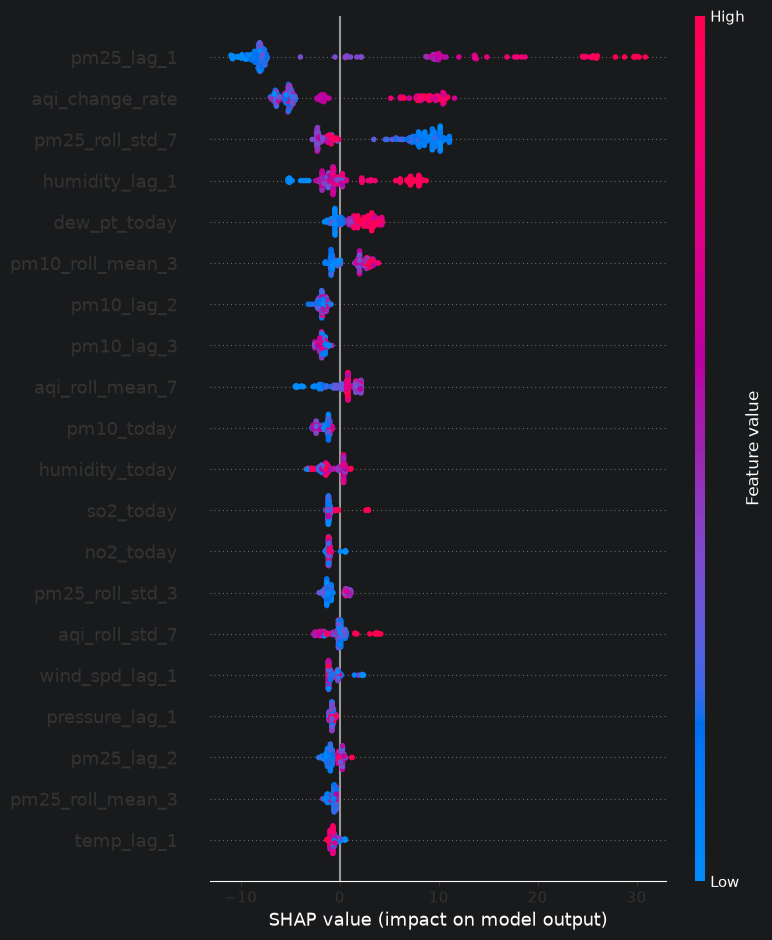

C:\Users\Lucky\AppData\Local\Temp\ipykernel_6996\157152556.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


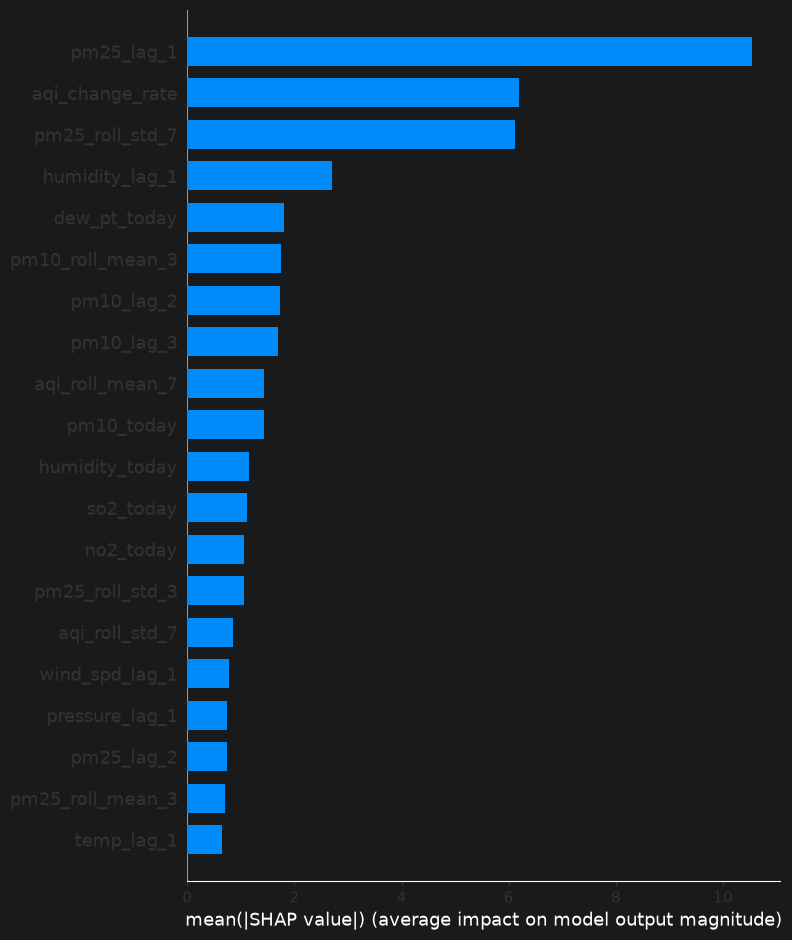

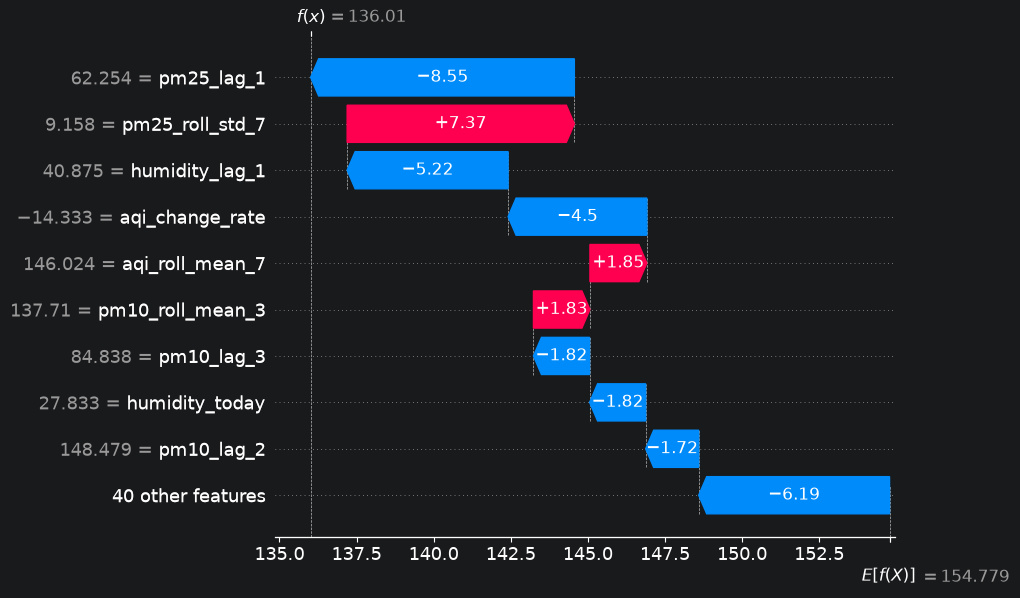

In [50]:
get_shap(ALL_TRAINING_FEATURES, best_model_lightbgm)